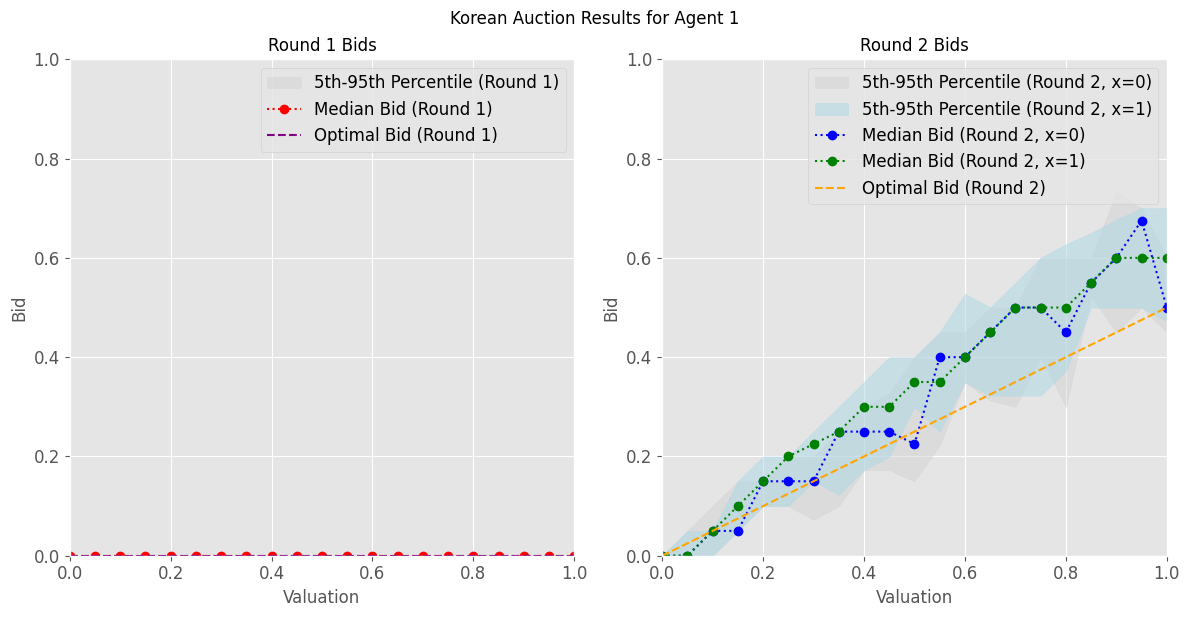

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(33454)
plt.style.use('ggplot')

def optimal_bidding_rule(valuations, num_agents=4):
    return (num_agents - 1) / num_agents * valuations

class QLearningAgent:
    def __init__(self, valuation_distribution=lambda: np.random.uniform(0, 1), action_min=0, action_max=1, granularity=21, epsilon=0.99, epsilon_decay=0.99995, epsilon_min=0.01, alpha=0.1, min_val=0, max_val=1):
        self.valuation_distribution = valuation_distribution
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.alpha = alpha
        self.min_val = min_val
        self.max_val = max_val
        self.granularity = granularity
        self.q_values_round_1 = np.random.uniform(0, 1, (granularity, 2, len(self.actions)))
        self.q_values_round_0 = np.random.uniform(0, 1, (granularity, len(self.actions)))
        self.reward_history = []
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)
        self.holds_highest_bid = 0

    def get_state(self, valuation):
        bin_centers = np.linspace(self.min_val, self.max_val, self.granularity)
        return np.argmin(np.abs(bin_centers - valuation))

    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def choose_action(self, round_number):
        valuation_state = self.state
        if round_number == 0:
            return np.random.choice(self.actions) if np.random.rand() < self.epsilon else self.actions[np.argmax(self.q_values_round_0[valuation_state])]
        else:
            return np.random.choice(self.actions) if np.random.rand() < self.epsilon else self.actions[np.argmax(self.q_values_round_1[valuation_state, self.holds_highest_bid])]

    def update_q_values(self, chosen_action, reward, round_number):
        action_index = np.where(self.actions == chosen_action)[0][0]
        if round_number == 0:
            self.q_values_round_0[self.state, action_index] += self.alpha * (reward - self.q_values_round_0[self.state, action_index])
        else:
            self.q_values_round_1[self.state, self.holds_highest_bid, action_index] += self.alpha * (reward - self.q_values_round_1[self.state, self.holds_highest_bid, action_index])

    def feedback(self, reward, action, round_number):
        self.reward_history.append(reward)
        self.update_q_values(action, reward, round_number)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)


class KoreanAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, epsilon_reward=0.01, win_reward=0.01, tie_break_x0=True):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.epsilon_reward = epsilon_reward
        self.win_reward = win_reward  # Added win reward for final winner
        self.tie_break_x0 = tie_break_x0
        self.profit_history = []

    def run_korean_auction(self):
        for agent in self.agents:
            agent.refresh_valuation()
        bids_round_0 = [max(self.price_floor, min(agent.choose_action(round_number=0), self.price_ceiling)) for agent in self.agents]
        
        highest_bid = max(bids_round_0)
        highest_bidder = [idx for idx, bid in enumerate(bids_round_0) if bid == highest_bid]  # Handle ties

        if len(highest_bidder) > 1 and self.tie_break_x0:
            # If tie_break_x0 is True, give x=0 to both in case of a tie
            for agent in self.agents:
                agent.holds_highest_bid = 0
        else:
            for idx, agent in enumerate(self.agents):
                agent.holds_highest_bid = 1 if idx in highest_bidder else 0

        bids_round_1 = [max(self.price_floor, min(agent.choose_action(round_number=1), self.price_ceiling)) for agent in self.agents]
        final_winner = np.argmax(bids_round_1)
        final_price = bids_round_1[final_winner]

        for idx, agent in enumerate(self.agents):
            reward_0 = agent.valuation - bids_round_0[idx] + self.epsilon_reward
            reward_1 = agent.valuation - final_price + self.epsilon_reward if idx == final_winner else 0
            if idx == final_winner:
                reward_1 += self.win_reward  # Add tiny reward for winning
            agent.feedback(reward_0, bids_round_0[idx], round_number=0)
            agent.feedback(reward_1, bids_round_1[idx], round_number=1)
            agent.decay_epsilon()

        self.profit_history.append((highest_bid, final_price))
        return {"winner": final_winner, "final_price": final_price, "bids_round_1": bids_round_1}


def run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=1000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    for sim in range(num_simulations):
        for _ in range(num_rounds):
            auction.run_korean_auction()
        for i, agent in enumerate(agents):
            avg_bids_round_1_x0 = [agent.actions[np.argmax(agent.q_values_round_1[state, 0])] for state in range(agent.granularity)]
            avg_bids_round_1_x1 = [agent.actions[np.argmax(agent.q_values_round_1[state, 1])] for state in range(agent.granularity)]
            avg_bids_round_0 = [agent.actions[np.argmax(agent.q_values_round_0[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append((avg_bids_round_0, avg_bids_round_1_x0, avg_bids_round_1_x1))

    percentiles = {}
    for i in range(len(agents)):
        bids_round_0 = np.array([b[0] for b in all_bids_for_valuations[i]])
        bids_round_1_x0 = np.array([b[1] for b in all_bids_for_valuations[i]])
        bids_round_1_x1 = np.array([b[2] for b in all_bids_for_valuations[i]])
        percentiles[i] = {
            "round_0": {
                "5th": np.percentile(bids_round_0, 5, axis=0),
                "median": np.median(bids_round_0, axis=0),
                "95th": np.percentile(bids_round_0, 95, axis=0),
            },
            "round_1_x0": {
                "5th": np.percentile(bids_round_1_x0, 5, axis=0),
                "median": np.median(bids_round_1_x0, axis=0),
                "95th": np.percentile(bids_round_1_x0, 95, axis=0),
            },
            "round_1_x1": {
                "5th": np.percentile(bids_round_1_x1, 5, axis=0),
                "median": np.median(bids_round_1_x1, axis=0),
                "95th": np.percentile(bids_round_1_x1, 95, axis=0),
            }
        }
    return percentiles


def plot_korean_auction_results(agent, percentiles, num_agents=4, title=None, fontsize=12):
    valuations = np.linspace(0, 1, agent.granularity)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1x2 grid for round 1 and round 2

    # Plot round 1
    ax1 = axes[0]
    ax1.fill_between(valuations, percentiles["round_0"]["5th"], percentiles["round_0"]["95th"], color='lightgray', alpha=0.5, label='5th-95th Percentile (Round 1)')
    ax1.plot(valuations, percentiles["round_0"]["median"], label=f'Median Bid (Round 1)', color='red', linestyle=':', marker='o')
    optimal_bids_round_1 = np.zeros_like(valuations)
    ax1.plot(valuations, optimal_bids_round_1, label=f'Optimal Bid (Round 1)', color='purple', linestyle='--')
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])
    ax1.set_xlabel('Valuation', fontsize=fontsize)
    ax1.set_ylabel('Bid', fontsize=fontsize)
    ax1.set_title('Round 1 Bids', fontsize=fontsize)
    ax1.legend(fontsize=fontsize)
    ax1.tick_params(axis='both', which='major', labelsize=fontsize)

    # Plot round 2
    ax2 = axes[1]
    ax2.fill_between(valuations, percentiles["round_1_x0"]["5th"], percentiles["round_1_x0"]["95th"], color='lightgray', alpha=0.5, label='5th-95th Percentile (Round 2, x=0)')
    ax2.fill_between(valuations, percentiles["round_1_x1"]["5th"], percentiles["round_1_x1"]["95th"], color='lightblue', alpha=0.5, label='5th-95th Percentile (Round 2, x=1)')
    ax2.plot(valuations, percentiles["round_1_x0"]["median"], label=f'Median Bid (Round 2, x=0)', color='blue', linestyle=':', marker='o')
    ax2.plot(valuations, percentiles["round_1_x1"]["median"], label=f'Median Bid (Round 2, x=1)', color='green', linestyle=':', marker='o')
    optimal_bids_round_2 = optimal_bidding_rule(valuations, num_agents=num_agents)
    ax2.plot(valuations, optimal_bids_round_2, label=f'Optimal Bid (Round 2)', color='orange', linestyle='--')
    ax2.set_xlim([0, 1])
    ax2.set_ylim([0, 1])
    ax2.set_xlabel('Valuation', fontsize=fontsize)
    ax2.set_ylabel('Bid', fontsize=fontsize)
    ax2.set_title('Round 2 Bids', fontsize=fontsize)
    ax2.legend(fontsize=fontsize)
    ax2.tick_params(axis='both', which='major', labelsize=fontsize)

    plt.tight_layout()
    if title:
        plt.suptitle(title, y=1.02, fontsize=fontsize)
    plt.show()


num_agents = 2  # Define the number of agents
agents = [QLearningAgent() for _ in range(num_agents)]
auction = KoreanAuction(agents, tie_break_x0=False)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=100000)
plot_korean_auction_results(agents[0], percentiles[0], num_agents=num_agents, title='Korean Auction Results for Agent 1')
